### IMPORTING IMPORTANT LIBRARIES

In [7]:
# !pip install numpy
# !pip install pandas
# !pip install matplotlib
# !c:\users\ajay\documents\sana\env\scripts\python.exe -m pip install --upgrade pip
# !pip install torch
# !pip install torchvision
# !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124
# !pip install scikit-learn
# !pip install seaborn
# !pip install tabulate

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
# torch.__version__
from torchvision import datasets, transforms, models  # datsets  , transforms
from torch.utils.data.sampler import SubsetRandomSampler
import torch.nn as nn
import torch.nn.functional as F
from datetime import datetime

In [17]:
torch.cuda.empty_cache()
torch.no_grad()
torch.cuda.synchronize()
!python3 --version

Python 3.8.10


### Import Dataset

<b> Dataset Link (Plant Vliiage Dataset ):</b><br> <a href='https://data.mendeley.com/datasets/tywbtsjrjv/1'> https://data.mendeley.com/datasets/tywbtsjrjv/1 </a>

In [18]:
transform = transforms.Compose(
    [transforms.Resize(255), transforms.CenterCrop(224), transforms.ToTensor()]
)

In [19]:
# The the link to where you have stored the dataset.
dataset = datasets.ImageFolder("All_Datasets/PlantVillage (Balanced Category wise)", transform=transform)

In [20]:
dataset

Dataset ImageFolder
    Number of datapoints: 78000
    Root location: All_Datasets/PlantVillage (Balanced Category wise)
    StandardTransform
Transform: Compose(
               Resize(size=255, interpolation=bilinear, max_size=None, antialias=True)
               CenterCrop(size=(224, 224))
               ToTensor()
           )

### Validation

In [21]:
# Suppose your dataset has integer class labels in dataset.targets
y = np.array(dataset.targets)

In [22]:
from sklearn.model_selection import StratifiedShuffleSplit

# --- Step 1: Create train+val vs. test (90% / 10%)
sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.10, random_state=42)
train_val_indices, test_indices = next(sss1.split(np.zeros(len(y)), y))

In [23]:
# --- Step 2: From train+val, split into train vs. validation
#  (We want validation to be 10% of the whole dataset, which is 1/9 of train+val)
sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.1111, random_state=42)
y_train_val = y[train_val_indices]
train_indices_sub, val_indices_sub = next(sss2.split(np.zeros(len(y_train_val)), y_train_val))


In [24]:
# Convert the local indices back to the original dataset’s indexing
train_indices = train_val_indices[train_indices_sub]
val_indices   = train_val_indices[val_indices_sub]

### Split into Train and Test

In [25]:
# Create samplers
train_sampler = SubsetRandomSampler(train_indices)
val_sampler = SubsetRandomSampler(val_indices)
test_sampler = SubsetRandomSampler(test_indices)

In [26]:
print("Train size:", len(train_indices))
print("Validation size:", len(val_indices))
print("Test size:", len(test_indices))

Train size: 62400
Validation size: 7800
Test size: 7800


In [27]:
targets_size = len(dataset.class_to_idx)
print(targets_size)

39


### Original Modeling - Only removed the final classification layer

In [28]:
class CNNFeatureExtractor(nn.Module):
    def __init__(self):
        super(CNNFeatureExtractor, self).__init__()
        
        # Same conv layers as your CNN
        self.conv_layers = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2),
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(2),
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(256),
            nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(256),
            nn.MaxPool2d(2),
        )

        # Replace your original dense_layers with a feature-extraction layer
        self.feature_layers = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(50176, 1024),
            nn.ReLU(),
            nn.Dropout(0.4)
            # Removed the final classification layer so we output a feature vector
        )

    def forward(self, X):
        out = self.conv_layers(X)
        # Flatten
        out = out.view(-1, 50176)
        out = self.feature_layers(out)   # shape: [B, 1024]
        return out

In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [30]:
model_original = CNNFeatureExtractor().to(device)

In [31]:
model_original.to(device)

CNNFeatureExtractor(
  (conv_layers): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU()
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU()
    (12): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1)

In [32]:
# !pip install torchsummary
from torchsummary import summary

summary(model_original, (3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 224, 224]             896
              ReLU-2         [-1, 32, 224, 224]               0
       BatchNorm2d-3         [-1, 32, 224, 224]              64
            Conv2d-4         [-1, 32, 224, 224]           9,248
              ReLU-5         [-1, 32, 224, 224]               0
       BatchNorm2d-6         [-1, 32, 224, 224]              64
         MaxPool2d-7         [-1, 32, 112, 112]               0
            Conv2d-8         [-1, 64, 112, 112]          18,496
              ReLU-9         [-1, 64, 112, 112]               0
      BatchNorm2d-10         [-1, 64, 112, 112]             128
           Conv2d-11         [-1, 64, 112, 112]          36,928
             ReLU-12         [-1, 64, 112, 112]               0
      BatchNorm2d-13         [-1, 64, 112, 112]             128
        MaxPool2d-14           [-1, 64,

### Hybrid Model with EfficientNet-B0

In [33]:
class HybridModelEfficientNet(nn.Module):
    def __init__(self, K):
        super(HybridModelEfficientNet, self).__init__()
        
        # Custom CNN for features
        self.custom_branch = CNNFeatureExtractor()
        
        # Pretrained EfficientNet-B0
        # Pretrained EfficientNet-B0 with updated weights parameter
        from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
        self.pretrained_branch = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
    
        # Remove the final classifier layer
        # Typically efficientnet_b0 has classifier = Sequential(...),
        # so we set it to Identity:
        self.pretrained_branch.classifier[1] = nn.Identity()  
        # Now it outputs a 1280-dim feature vector
        
        # Fusion layer: combine 1024 (custom) + 1280 (EfficientNet) = 2304
        self.fusion = nn.Sequential(
            nn.Linear(1024 + 1280, 1024),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(1024, K)
        )

    def forward(self, X):
        feat_custom = self.custom_branch(X)                # [B, 1024]
        feat_pretrained = self.pretrained_branch(X)        # [B, 1280]
        combined_feats = torch.cat([feat_custom, feat_pretrained], dim=1)  # [B, 2304]
        out = self.fusion(combined_feats)                  # [B, K]
        return out

In [34]:
model = HybridModelEfficientNet(targets_size).to(device)

In [35]:
model.to(device)

HybridModelEfficientNet(
  (custom_branch): CNNFeatureExtractor(
    (conv_layers): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): ReLU()
      (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (8): ReLU()
      (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (11): ReLU()
      (12): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ce

In [36]:
from torchsummary import summary
summary(model, (3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 224, 224]             896
              ReLU-2         [-1, 32, 224, 224]               0
       BatchNorm2d-3         [-1, 32, 224, 224]              64
            Conv2d-4         [-1, 32, 224, 224]           9,248
              ReLU-5         [-1, 32, 224, 224]               0
       BatchNorm2d-6         [-1, 32, 224, 224]              64
         MaxPool2d-7         [-1, 32, 112, 112]               0
            Conv2d-8         [-1, 64, 112, 112]          18,496
              ReLU-9         [-1, 64, 112, 112]               0
      BatchNorm2d-10         [-1, 64, 112, 112]             128
           Conv2d-11         [-1, 64, 112, 112]          36,928
             ReLU-12         [-1, 64, 112, 112]               0
      BatchNorm2d-13         [-1, 64, 112, 112]             128
        MaxPool2d-14           [-1, 64,

### Early Stopping

In [37]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.0001):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = None
        self.counter = 0

    def step(self, current_loss):
        if self.best_loss is None or current_loss < self.best_loss - self.min_delta:
            self.best_loss = current_loss
            self.counter = 0
            return False  # Do not stop
        else:
            self.counter += 1
            if self.counter >= self.patience:
                return True   # Stop training
            return False

early_stopping = EarlyStopping(patience=5, min_delta=0.0001)


In [38]:
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0001, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

In [39]:
# Cosine Annealing LR Scheduler
# The learning rate resets every 10 epochs, allowing the model to explore different solutions.
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

current_lr = scheduler.get_last_lr()[0]  # gets the learning rate from the first param group
print(f"Current Learning Rate: {current_lr}")

Current Learning Rate: 0.0001


### Load Model

In [40]:
# Reinitialize your model architecture
targets_size = 39
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = HybridModelEfficientNet(targets_size).to(device)

# Load the full checkpoint (includes training history)
full_checkpoint = torch.load("Hybrid/PlantVillage/hybrid_model_d02.pt", map_location=device)
model.load_state_dict(full_checkpoint['model_state_dict'])

# Optionally, retrieve training history
train_losses = full_checkpoint.get('train_losses', None)
validation_losses   = full_checkpoint.get('val_losses', None)
epoch        = full_checkpoint.get('epoch', None)

# Set model to evaluation mode
model.eval()

# (Optional) Verify the device of each parameter
for name, param in model.named_parameters():
    print(f"{name} is on {param.device}")

C:\Users\AJAY\AppData\Local\Temp\ipykernel_24208\1410530207.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  full_checkpoint = torch.load("Hybrid/PlantVillage/hybrid_mode

custom_branch.conv_layers.0.weight is on cuda:0
custom_branch.conv_layers.0.bias is on cuda:0
custom_branch.conv_layers.2.weight is on cuda:0
custom_branch.conv_layers.2.bias is on cuda:0
custom_branch.conv_layers.3.weight is on cuda:0
custom_branch.conv_layers.3.bias is on cuda:0
custom_branch.conv_layers.5.weight is on cuda:0
custom_branch.conv_layers.5.bias is on cuda:0
custom_branch.conv_layers.7.weight is on cuda:0
custom_branch.conv_layers.7.bias is on cuda:0
custom_branch.conv_layers.9.weight is on cuda:0
custom_branch.conv_layers.9.bias is on cuda:0
custom_branch.conv_layers.10.weight is on cuda:0
custom_branch.conv_layers.10.bias is on cuda:0
custom_branch.conv_layers.12.weight is on cuda:0
custom_branch.conv_layers.12.bias is on cuda:0
custom_branch.conv_layers.14.weight is on cuda:0
custom_branch.conv_layers.14.bias is on cuda:0
custom_branch.conv_layers.16.weight is on cuda:0
custom_branch.conv_layers.16.bias is on cuda:0
custom_branch.conv_layers.17.weight is on cuda:0
cus

### Single Prediction

In [41]:
from PIL import Image
import torchvision.transforms.functional as TF

In [42]:
transform_index_to_disease = dataset.class_to_idx

transform_index_to_disease = dict(
    [(value, key) for key, value in transform_index_to_disease.items()]
)  # reverse the index

In [43]:
# 1) Pick the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2) Move your model to the device
model.to(device)
# model.eval()

HybridModelEfficientNet(
  (custom_branch): CNNFeatureExtractor(
    (conv_layers): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): ReLU()
      (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (8): ReLU()
      (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (11): ReLU()
      (12): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ce

In [44]:
data = pd.read_csv("disease_info.csv", encoding="cp1252")

In [45]:
def display_image(image_path):
    """
    Loads and displays the leaf image.
    """
    img = Image.open(image_path).convert("RGB").resize((224, 224))
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis('off')
    plt.title("Input Leaf")
    plt.show()
    return img  # return the PIL image for further processing

In [46]:
def single_prediction(image_path):
    """
    Displays the image, runs the model, and prints the predicted disease.
    """
    # Display
    img = display_image(image_path)

    # Preprocess
    input_tensor = TF.to_tensor(img).unsqueeze(0).to(device)  # shape: (1,3,224,224)

    # Inference
    with torch.no_grad():
        logits = model(input_tensor)

    # Postprocess
    probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
    idx = np.argmax(probs)
    disease = data['disease_name'].iloc[idx]
    confidence = probs[idx] * 100

    print(f"Predicted disease: {disease} \n{confidence:.1f}% confidence")

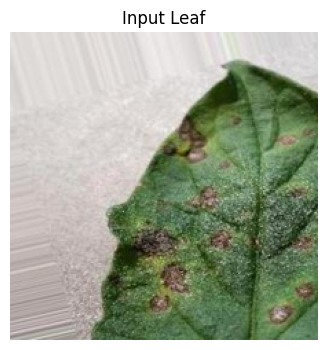

Predicted disease: Tomato : Early Blight 
91.6% confidence


In [47]:
single_prediction("All_Datasets/PlantVillage (Balanced Category wise)/Tomato___Early_blight/image (16)_aug_68.JPG")

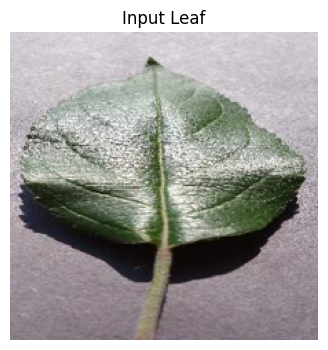

Predicted disease: Apple : Healthy 
89.2% confidence


In [48]:
single_prediction("All_Datasets/PlantVillage (Balanced Category wise)/Apple___healthy/image (3).JPG")

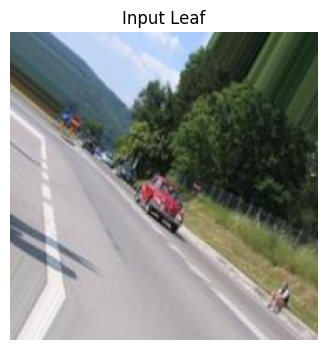

Predicted disease: Background Without Leaves 
88.6% confidence


In [49]:
single_prediction("All_Datasets/PlantVillage (Balanced Category wise)/Background_without_leaves/image (3)_aug_366.jpg")

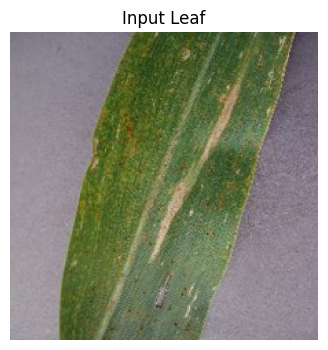

Predicted disease: Corn : Northern Leaf Blight 
91.8% confidence


In [50]:
single_prediction("All_Datasets/PlantVillage (Balanced Category wise)/Corn___Northern_Leaf_Blight/image (6).JPG")

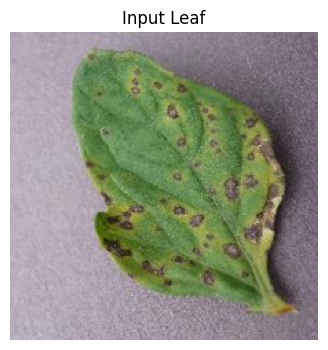

Predicted disease: Tomato : Septoria Leaf Spot 
86.8% confidence


In [51]:
single_prediction("All_Datasets/PlantVillage (Balanced Category wise)/Tomato___Septoria_leaf_spot/image (8).JPG")